<a href="https://colab.research.google.com/github/jampsss/Probabilidad-yEstadistica/blob/main/Unidad1/PRO_U1_practica3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Probabilidad y estadistica**

##**Unidad 1**

###**Practica 3. Tabla de Frecuencias y regla de Sturges..**
###Docente: *Dr. Jose Gabriel Rodriguez Rivas*
### Alumno:Luis Enrique Lerma Romero


In [10]:
#basado en el libro estadistica para la administracion pagina 12
#creamos una lista vacia que representa la edad de 100 personas
import random
edades=[]
#HACEMOS un ciclo para generar 100 numeros aleatorios  que representan la edad de las personas
for i in range(100):
    #numero aleatorio funcion radint y lo guardamos en la variable
    numero_aleatorio=random.randint(18,70)
    #agregamos el numero aleatorio con la funcion radint y lo guardamos en la variable
    edades.append(numero_aleatorio)
print(edades)

[41, 39, 41, 41, 27, 57, 34, 67, 26, 51, 26, 41, 58, 55, 34, 63, 30, 41, 32, 53, 30, 27, 70, 24, 43, 51, 47, 30, 43, 42, 55, 53, 44, 42, 63, 63, 48, 37, 58, 55, 62, 47, 42, 23, 18, 45, 42, 41, 59, 18, 66, 57, 42, 60, 46, 39, 28, 46, 35, 33, 32, 44, 56, 48, 54, 55, 43, 60, 43, 20, 21, 63, 27, 31, 26, 23, 22, 22, 54, 52, 52, 53, 70, 62, 37, 24, 32, 25, 58, 53, 47, 39, 44, 25, 50, 49, 36, 48, 20, 63]


In [11]:
import pandas as pd
#crear un dataframe de pandas con los numeros aleatorios
df=pd.DataFrame(edades, columns=['Edad'])
df.head()

,Edad
0,41
1,39
2,41
3,41
4,27


In [14]:
#Calcular la tabla de distribucion de frecuencias
tabla_frecuencias=df['Edad'].value_counts().reset_index()
tabla_frecuencias.columns=['Edad','Frecuencia']
tabla_frecuencias=tabla_frecuencias.sort_values(by='Edad')

#imprimir la  tabla de distribucion de frecuencias
print("Tabla de distribucion de frecuencias:")
tabla_frecuencias

Tabla de distribucion de frecuencias:


,Edad,Frecuencia
24,18,2
30,20,2
40,21,1
16,22,2
23,23,2
19,24,2
29,25,2
10,26,3
9,27,3
38,28,1


**FRECUENCIA RELATIVA**

In [15]:
tabla_frecuencias['Frec Relativa'] = tabla_frecuencias['Frecuencia']/100
tabla_frecuencias


,Edad,Frecuencia,Frec Relativa
24,18,2,0.02
30,20,2,0.02
40,21,1,0.01
16,22,2,0.02
23,23,2,0.02
19,24,2,0.02
29,25,2,0.02
10,26,3,0.03
9,27,3,0.03
38,28,1,0.01


**FRECUENCIA PORCENTUAL**

In [16]:
tabla_frecuencias['Frec Porcentual'] = tabla_frecuencias['Frecuencia']/100*100
tabla_frecuencias


,Edad,Frecuencia,Frec Relativa,Frec Porcentual
24,18,2,0.02,2.0
30,20,2,0.02,2.0
40,21,1,0.01,1.0
16,22,2,0.02,2.0
23,23,2,0.02,2.0
19,24,2,0.02,2.0
29,25,2,0.02,2.0
10,26,3,0.03,3.0
9,27,3,0.03,3.0
38,28,1,0.01,1.0


**FRECUENCIA ACUMULADA**



In [17]:
tabla_frecuencias['Frec acumulada'] = tabla_frecuencias['Frecuencia'].cumsum()
tabla_frecuencias

,Edad,Frecuencia,Frec Relativa,Frec Porcentual,Frec acumulada
24,18,2,0.02,2.0,2
30,20,2,0.02,2.0,4
40,21,1,0.01,1.0,5
16,22,2,0.02,2.0,7
23,23,2,0.02,2.0,9
19,24,2,0.02,2.0,11
29,25,2,0.02,2.0,13
10,26,3,0.03,3.0,16
9,27,3,0.03,3.0,19
38,28,1,0.01,1.0,20


# **Regla de Sturges**
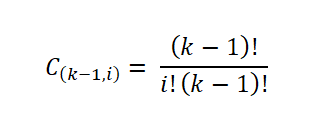

In [18]:
#immportamnops la libreria math
import math
print(edades)

[41, 39, 41, 41, 27, 57, 34, 67, 26, 51, 26, 41, 58, 55, 34, 63, 30, 41, 32, 53, 30, 27, 70, 24, 43, 51, 47, 30, 43, 42, 55, 53, 44, 42, 63, 63, 48, 37, 58, 55, 62, 47, 42, 23, 18, 45, 42, 41, 59, 18, 66, 57, 42, 60, 46, 39, 28, 46, 35, 33, 32, 44, 56, 48, 54, 55, 43, 60, 43, 20, 21, 63, 27, 31, 26, 23, 22, 22, 54, 52, 52, 53, 70, 62, 37, 24, 32, 25, 58, 53, 47, 39, 44, 25, 50, 49, 36, 48, 20, 63]


In [24]:
#dataframe con las edades
df=pd.DataFrame({'Edad' : edades})
df

,Edad
0,41
1,39
2,41
3,41
4,27
...,...
95,49
96,36
97,48
98,20


In [25]:
#calcular el numero de intervalos utilizando la regla
n=len(edades)
k=int(1+math.log2(n))
print("Valor de n= ", n, " \nNumero de intervalos=", k)



Valor de n=  100  
Numero de intervalos= 7


In [28]:
#Crear tabla de frecuencia
tabla_frecuencia=pd.cut(df['Edad'],bins=k,include_lowest=True).value_counts().reset_index()
tabla_frecuencia.columns=['Clase', 'Frec']
tabla_frecuencia

,Clase,Frec
0,"(40.286, 47.714]",24
1,"(47.714, 55.143]",19
2,"(25.429, 32.857]",14
3,"(17.947, 25.429]",13
4,"(55.143, 62.571]",11
5,"(32.857, 40.286]",10
6,"(62.571, 70.0]",9


In [29]:
#ordenar la tabla por intervalo
tabla_frecuencia=tabla_frecuencia.sort_values(by='Clase')


In [31]:
#generar columnas siguientes
tabla_frecuencia['Frec Rel']=tabla_frecuencia['Frec']/n
tabla_frecuencia['Frec Porc']=tabla_frecuencia['Frec']/n*100
tabla_frecuencia['Frec Ac']=tabla_frecuencia['Frec'].cumsum()
tabla_frecuencia['Frec Porc ac']=tabla_frecuencia['Frec Porc'].cumsum()
#mostrar la tabla
print(tabla_frecuencia)

              Clase  Frec  Frec Rel  Frec Porc  Frec Ac  Frec Porc ac
3  (17.947, 25.429]    13      0.13       13.0       13          13.0
2  (25.429, 32.857]    14      0.14       14.0       27          27.0
5  (32.857, 40.286]    10      0.10       10.0       37          37.0
0  (40.286, 47.714]    24      0.24       24.0       61          61.0
1  (47.714, 55.143]    19      0.19       19.0       80          80.0
4  (55.143, 62.571]    11      0.11       11.0       91          91.0
6    (62.571, 70.0]     9      0.09        9.0      100         100.0


Text(0.5, 1.0, 'Histograma de edades basado en la funcion de matplotlib con valores estandar')

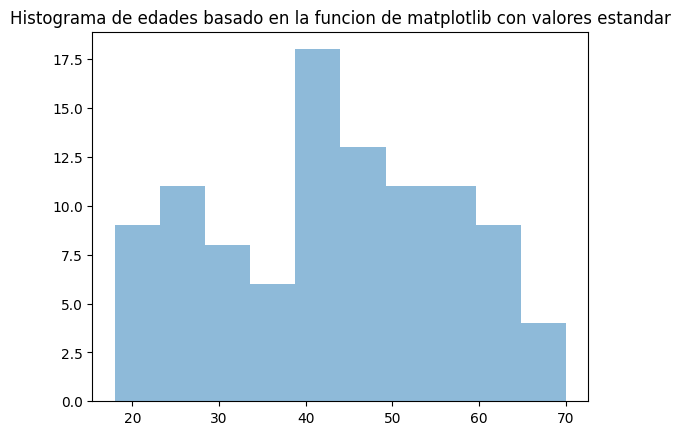

In [33]:
import matplotlib.pyplot as plt
plt.hist(edades,alpha=0.5)
plt.title('Histograma de edades basado en la funcion de matplotlib con valores estandar')

Text(0, 0.5, 'Frecuencia')

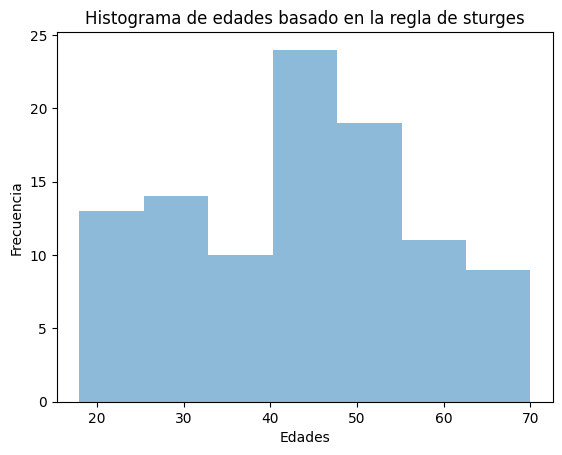

In [34]:
#crear un histograma basado en la tabla de frecuencia
plt.hist(df['Edad'], bins=k,alpha=0.5)
plt.title('Histograma de edades basado en la regla de sturges')
plt.xlabel('Edades')
plt.ylabel('Frecuencia')